In [4]:
import rasterio as rio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
LANDSAT_YEARS = [2000, 2005, 2010, 2015, 2020, 2025]
S1_YEARS = [2018, 2020, 2025]
LANDSAT_PATHS = [
    f"https://storage.googleapis.com/gee-ramiqcom-s4g-bucket/oil_palm_papua/glad_ard/papua_selatan_oil_palm_GLAD_ARD_{year}-01-01_{year}-12-31_30m.tif"
    for year in LANDSAT_YEARS
]
S1_PATHS = [
    f"https://storage.googleapis.com/gee-ramiqcom-s4g-bucket/oil_palm_papua/s1/papua_selatan_oil_S1_RTC_composite_{year}-05-20_{year}-08-31_30m.tif" for year in S1_YEARS
]

In [5]:
def rescale(array: np.ndarray, src:tuple[float, float]):
    return (array - src[0]) / (src[1] - src[0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.33333334..1.6003333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.33333334..1.5566666].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.33333334..1.5236666].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.333..1.7702857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.33333334..1.57].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.33333334..2.7736666].


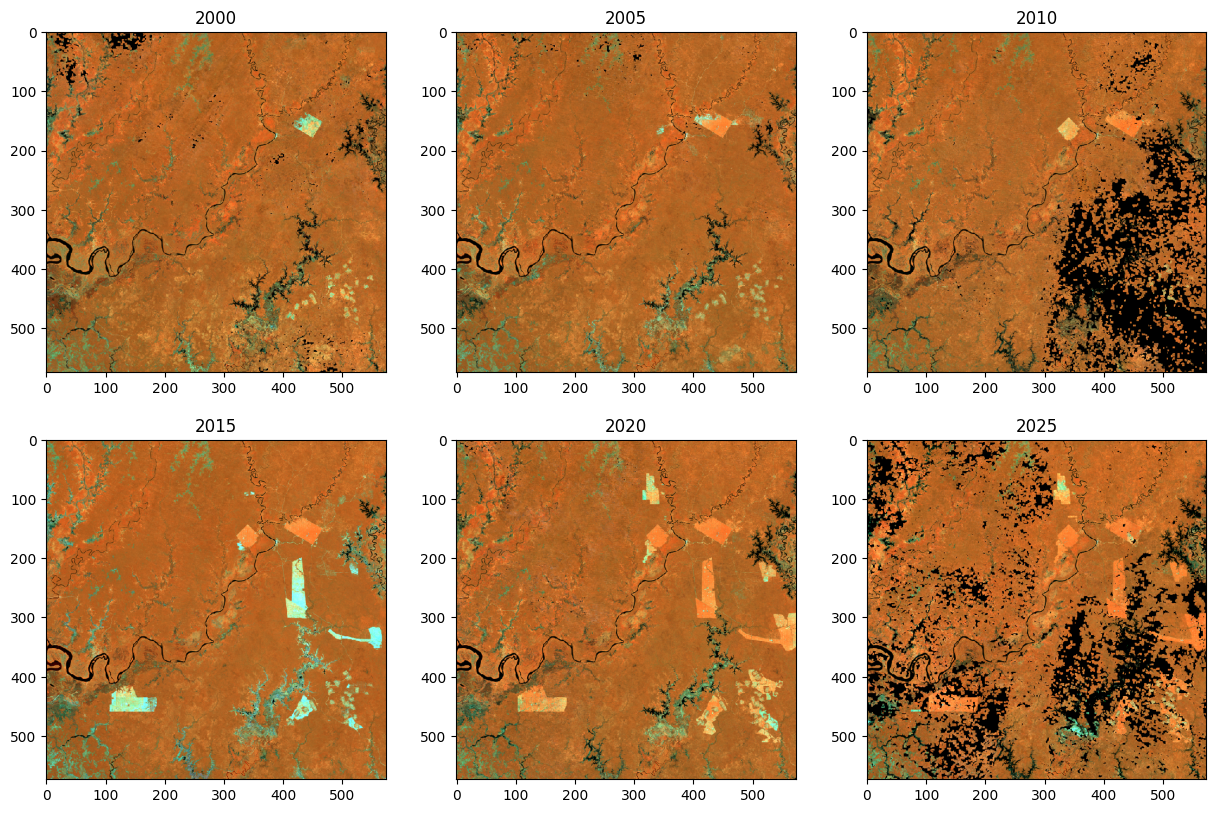

In [24]:
fig = plt.figure(figsize=(15, 15))
for index in range(len(LANDSAT_YEARS)):
    year = LANDSAT_YEARS[index]
    path = LANDSAT_PATHS[index]

    with rio.open(path) as src:
        bounds = tuple(src.bounds)
        height = int(src.height / 10)
        width = int(src.width / 10)
        nir, swir1, swir2 = src.read([4, 5, 6], out_shape=(height, width), out_dtype="float32")

        composite = np.dstack([
            rescale(nir, [1000, 4000]),
            rescale(swir1, [500, 3000]),
            rescale(swir2, [250, 2000])
        ])
        
        plt.subplot(3, 3, index + 1)
        plt.title(year)
        plt.imshow(composite)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.925926..4.6175].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9272728..6.516].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9285715..6.4485].


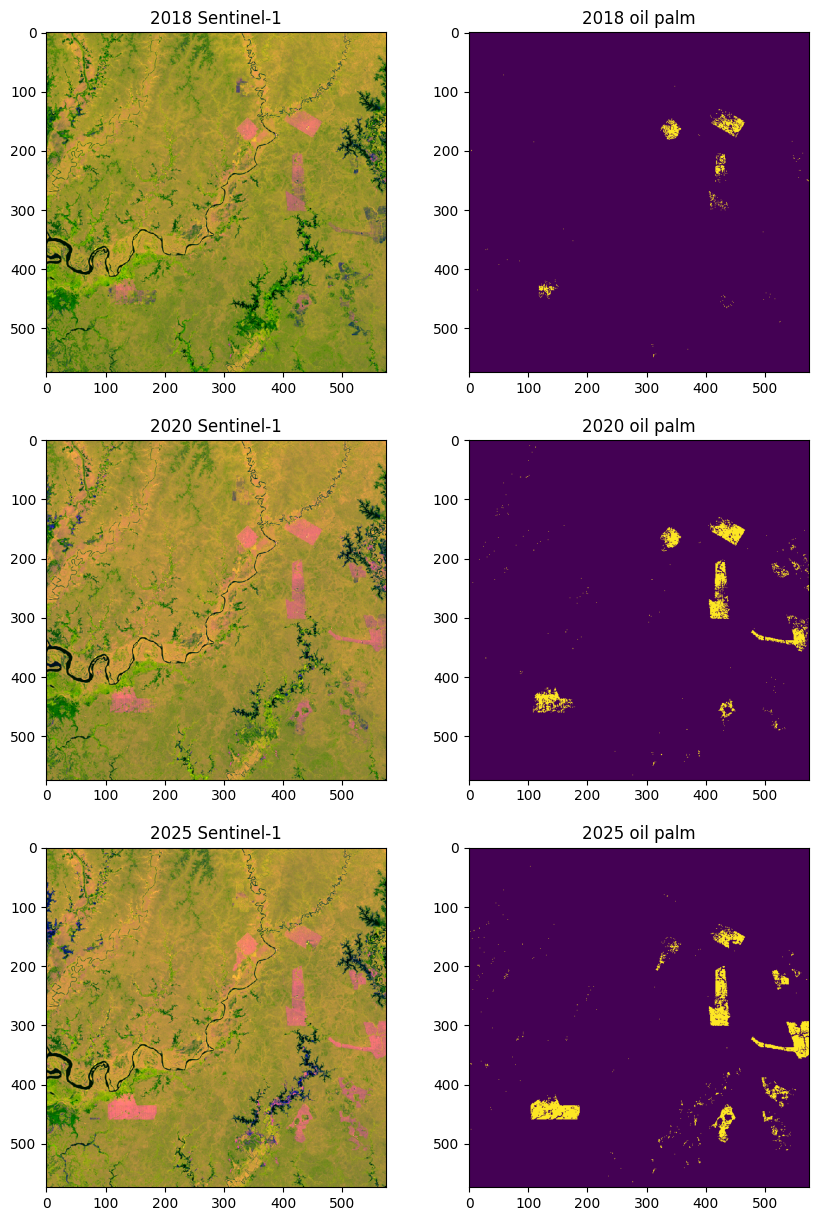

In [56]:
fig = plt.figure(figsize=(10, 15))
for index in range(len(S1_YEARS)):
    year = S1_YEARS[index]
    path = S1_PATHS[index]

    with rio.open(path) as src:
        height = int(src.height / 10)
        width = int(src.width / 10)
        vv, vh = src.read(out_shape=(height, width), out_dtype="float32")
        rvi = (vv - vh )/ (vv + vh)

        composite = np.dstack([
            rescale(vv, [1000, 3000]),
            rescale(vh, [0, 1000]),
            rescale(rvi, [0.5, 1])
        ])

        oil_palm = (vv > 2500) & (rvi > 0.6) & (vh < 500)
        
        plt.subplot(3, 2, (index * 2 + 1))
        plt.title(f"{year} Sentinel-1")
        plt.imshow(composite)

        plt.subplot(3, 2, (index * 2 + 2))
        plt.title(f"{year} oil palm")
        plt.imshow(oil_palm)
